In [1]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.
Matplotlib is building the font cache; this may take a moment.


In [2]:
k = 0.4
L = 1
n = 1

In [3]:
geom = dde.geometry.Interval(0, L)
timedomain = dde.geometry.TimeDomain(0, n)
geom_time = dde.geometry.GeometryXTime(geometry=geom, timedomain=timedomain)

In [6]:
ic = dde.icbc.IC(geom_time, lambda x: np.sin(n * np.pi * x[:, 0:1]/L), lambda _, on_initial: on_initial)

In [7]:
lambda_double = lambda x : 2*x[:, 0:1]
bc = dde.icbc.DirichletBC(geom_time,  lambda input_array: lambda_double(input_array), lambda _, on_boundary: on_boundary)

In [8]:
def pde(comp, u):
    du_t = dde.grad.jacobian(u, comp, i=0, j=1)
    du_xx = dde.grad.hessian(u, comp, i=0, j=0)
    return du_t - k * du_xx

In [9]:
data = dde.data.TimePDE(geom_time, pde, [bc, ic], num_domain=2540, num_boundary=80, num_initial=160, num_test=2540)

In [11]:
net = dde.nn.FNN([2] + [20] * 3 + [1], "tanh", "Glorot normal")

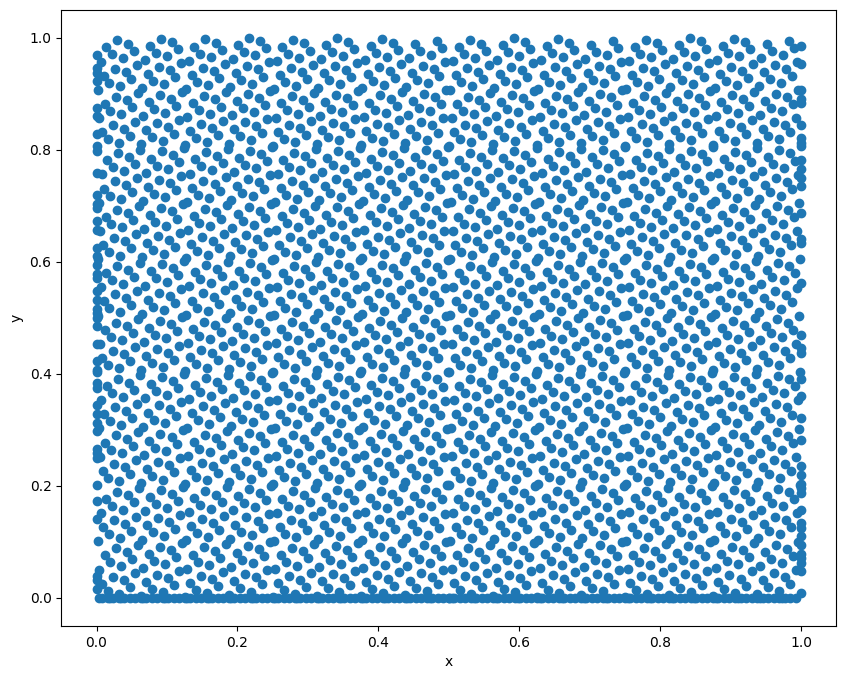

In [12]:
plt.figure(figsize=(10,8))
plt.scatter(data.train_x_all[:,0], data.train_x_all[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [13]:
model = dde.Model(data=data, net=net)
model.compile("adam", lr=1e-3)

Compiling model...
'compile' took 1.628399 s



In [14]:
loss_history, train_state = model.train(iterations=15000)

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.14e-01, 2.26e+00, 4.97e-01]    [1.08e-01, 2.26e+00, 4.97e-01]    []  


/home/haniel/.local/lib/python3.10/site-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [7.95e-03, 6.86e-02, 1.78e-01]    [5.97e-03, 6.86e-02, 1.78e-01]    []  
2000      [1.03e-02, 4.45e-02, 5.47e-02]    [5.30e-03, 4.45e-02, 5.47e-02]    []  
3000      [4.02e-03, 3.00e-02, 2.23e-02]    [2.01e-03, 3.00e-02, 2.23e-02]    []  
4000      [3.34e-03, 2.40e-02, 1.49e-02]    [1.85e-03, 2.40e-02, 1.49e-02]    []  
5000      [5.56e-03, 2.30e-02, 1.01e-02]    [3.66e-03, 2.30e-02, 1.01e-02]    []  
6000      [2.25e-03, 1.93e-02, 9.70e-03]    [1.33e-03, 1.93e-02, 9.70e-03]    []  
7000      [2.04e-03, 1.83e-02, 8.79e-03]    [1.25e-03, 1.83e-02, 8.79e-03]    []  
8000      [1.86e-03, 1.77e-02, 8.05e-03]    [1.12e-03, 1.77e-02, 8.05e-03]    []  
9000      [1.69e-03, 1.69e-02, 7.83e-03]    [1.04e-03, 1.69e-02, 7.83e-03]    []  
10000     [3.99e-03, 1.54e-02, 8.83e-03]    [2.23e-03, 1.54e-02, 8.83e-03]    []  
11000     [1.52e-03, 1.58e-02, 7.22e-03]    [9.44e-04, 1.58e-02, 7.22e-03]    []  
12000     [1.43e-03, 1.53e-02, 6.99e-03]    [8.80e-04, 1.53e-02, 6.99e-03]    []  
1300

#### Limited-memory Broyden-Fletcher-Goldfarb-Shanno

In [15]:
model.compile("L-BFGS-B")
loss_history, train_state = model.train()

Compiling model...
'compile' took 0.002022 s

Training model...

Step      Train loss                        Test loss                         Test metric
15000     [1.23e-03, 1.39e-02, 6.48e-03]    [6.98e-04, 1.39e-02, 6.48e-03]    []  

Best model at step 15000:
  train loss: 2.16e-02
  test loss: 2.11e-02
  test metric: []

'train' took 0.015610 s



Saving loss history to /home/haniel/Projects/Python/PINNs/1D Heat Equation/loss.dat ...
Saving training data to /home/haniel/Projects/Python/PINNs/1D Heat Equation/train.dat ...
Saving test data to /home/haniel/Projects/Python/PINNs/1D Heat Equation/test.dat ...


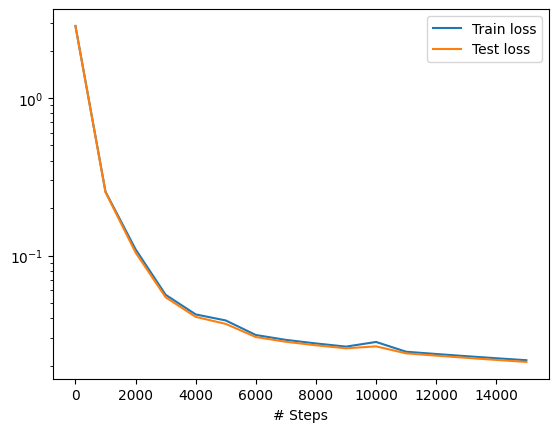

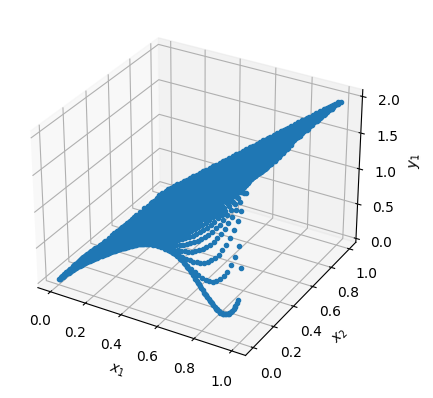

In [17]:
dde.saveplot(loss_history=loss_history, train_state=train_state,issave=True, isplot=True)